In [1]:
from pathlib import Path

dataset_path = Path(
    "../../data/item_images/raw/charger_source2_roboflow"
)

print("Exists:", dataset_path.exists())

for path in dataset_path.rglob("*"):
    if path.is_dir():
        print(path)

Exists: True
..\..\data\item_images\raw\charger_source2_roboflow\test
..\..\data\item_images\raw\charger_source2_roboflow\train
..\..\data\item_images\raw\charger_source2_roboflow\valid
..\..\data\item_images\raw\charger_source2_roboflow\test\images
..\..\data\item_images\raw\charger_source2_roboflow\test\labels
..\..\data\item_images\raw\charger_source2_roboflow\train\images
..\..\data\item_images\raw\charger_source2_roboflow\train\labels
..\..\data\item_images\raw\charger_source2_roboflow\valid\images
..\..\data\item_images\raw\charger_source2_roboflow\valid\labels


In [2]:
from collections import Counter

extensions = Counter()

for file in dataset_path.rglob("*"):
    if file.is_file():
        extensions[file.suffix.lower()] += 1

print(extensions)

Counter({'.txt': 225, '.jpg': 223, '.yaml': 1})


In [3]:
yaml_files = list(dataset_path.rglob("*.yaml"))

print("YAML files:", yaml_files)

if yaml_files:
    with open(yaml_files[0], "r") as f:
        print(f.read())

YAML files: [WindowsPath('../../data/item_images/raw/charger_source2_roboflow/data.yaml')]
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 1
names: ['mobile_charger']

roboflow:
  workspace: yashs-workspace-qeaqs
  project: mobile-charger-detection
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/yashs-workspace-qeaqs/mobile-charger-detection/dataset/1


In [4]:
image_extensions = {".jpg", ".jpeg", ".png", ".webp"}

for split in ["train", "valid", "test"]:

    image_dir = dataset_path / split / "images"
    label_dir = dataset_path / split / "labels"

    images = (
        [
            f for f in image_dir.iterdir()
            if f.suffix.lower() in image_extensions
        ]
        if image_dir.exists()
        else []
    )

    labels = (
        list(label_dir.glob("*.txt"))
        if label_dir.exists()
        else []
    )

    print(
        split,
        "| images:", len(images),
        "| labels:", len(labels)
    )

train | images: 156 | labels: 156
valid | images: 45 | labels: 45
test | images: 22 | labels: 22


In [5]:
from pathlib import Path

image_extensions = {".jpg", ".jpeg", ".png", ".webp"}

all_images = []
all_labels = []

for split in ["train", "valid", "test"]:

    image_dir = dataset_path / split / "images"
    label_dir = dataset_path / split / "labels"

    split_images = [
        f for f in image_dir.iterdir()
        if f.suffix.lower() in image_extensions
    ]

    split_labels = list(label_dir.glob("*.txt"))

    all_images.extend([(split, f) for f in split_images])
    all_labels.extend([(split, f) for f in split_labels])

print("Total images:", len(all_images))
print("Total labels:", len(all_labels))

Total images: 223
Total labels: 223


In [6]:
keywords = [
    "flipped",
    "flip",
    "rotate",
    "rotated",
    "aug",
    "bright",
    "blur"
]

for keyword in keywords:

    matches = [
        image_path.name
        for split, image_path in all_images
        if keyword.lower() in image_path.name.lower()
    ]

    print(keyword, ":", len(matches))

    for name in matches[:5]:
        print("   ", name)

flipped : 0
flip : 0
rotate : 0
rotated : 0
aug : 0
bright : 0
blur : 0


In [7]:
for split in ["train", "valid", "test"]:

    image_dir = dataset_path / split / "images"
    label_dir = dataset_path / split / "labels"

    images = [
        f for f in image_dir.iterdir()
        if f.suffix.lower() in image_extensions
    ]

    labels = list(label_dir.glob("*.txt"))

    image_stems = {f.stem for f in images}
    label_stems = {f.stem for f in labels}

    print(f"\n{split.upper()}")
    print("Images without labels:", len(image_stems - label_stems))
    print("Labels without images:", len(label_stems - image_stems))


TRAIN
Images without labels: 0
Labels without images: 0

VALID
Images without labels: 0
Labels without images: 0

TEST
Images without labels: 0
Labels without images: 0


In [8]:
def windows_long_path(path):
    path = Path(path).resolve()
    return "\\\\?\\" + str(path)

In [9]:
from collections import Counter

object_count_distribution = Counter()
class_ids = Counter()
total_objects = 0

for split, label_file in all_labels:

    with open(windows_long_path(label_file), "r") as f:
        lines = [
            line.strip()
            for line in f
            if line.strip()
        ]

    object_count_distribution[len(lines)] += 1
    total_objects += len(lines)

    for line in lines:
        class_id = int(line.split()[0])
        class_ids[class_id] += 1

print("Total images:", len(all_images))
print("Total charger objects:", total_objects)

print("\nObjects per image:")
for count, num_images in sorted(object_count_distribution.items()):
    print(count, "object(s):", num_images, "images")

print("\nClass IDs:")
print(class_ids)

Total images: 223
Total charger objects: 284

Objects per image:
1 object(s): 194 images
2 object(s): 20 images
3 object(s): 4 images
4 object(s): 1 images
6 object(s): 1 images
8 object(s): 1 images
9 object(s): 1 images
11 object(s): 1 images

Class IDs:
Counter({0: 284})


In [10]:
from PIL import Image
from collections import Counter

size_counts = Counter()
corrupt_images = []

for split, image_path in all_images:

    try:
        with Image.open(windows_long_path(image_path)) as img:
            size_counts[img.size] += 1
            img.verify()

    except Exception as e:
        corrupt_images.append(
            (split, image_path.name, str(e))
        )

print("Image dimensions:")
print(size_counts)

print("\nCorrupt images:", len(corrupt_images))

for item in corrupt_images[:10]:
    print(item)

Image dimensions:
Counter({(640, 640): 223})

Corrupt images: 0


In [11]:
import pandas as pd

charger_rows = []

for split, label_file in all_labels:

    with open(windows_long_path(label_file), "r") as f:
        lines = [
            line.strip()
            for line in f
            if line.strip()
        ]

    bbox_ratios = []

    for line in lines:

        values = line.split()

        width = float(values[3])
        height = float(values[4])

        bbox_ratios.append(width * height)

    charger_rows.append({
        "file_name": label_file.stem + ".jpg",
        "original_split": split,
        "object_count": len(lines),
        "largest_bbox_ratio": max(bbox_ratios)
    })

charger2_df = pd.DataFrame(charger_rows)

print(charger2_df.shape)

print("\nLargest bbox statistics:")
print(
    charger2_df["largest_bbox_ratio"]
    .describe()
)

(223, 4)

Largest bbox statistics:
count    223.000000
mean       0.155260
std        0.146751
min        0.001648
25%        0.035232
50%        0.093518
75%        0.253654
max        0.677912
Name: largest_bbox_ratio, dtype: float64



SPLIT: train


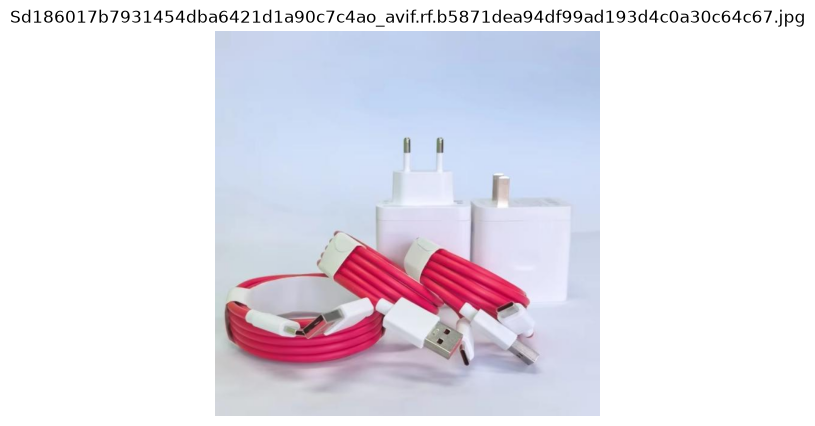

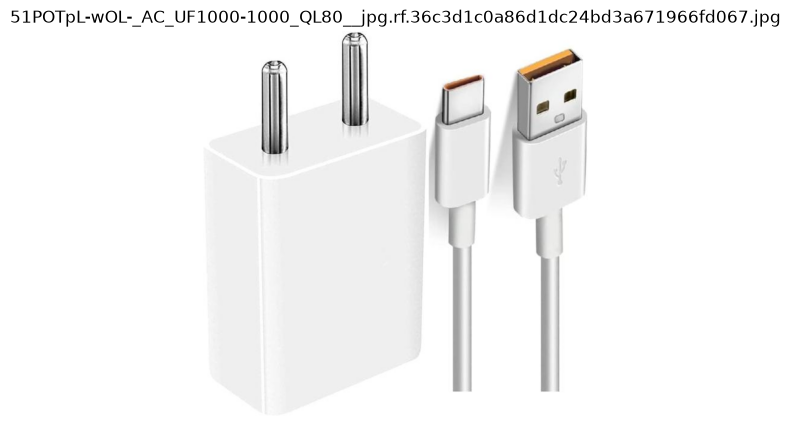

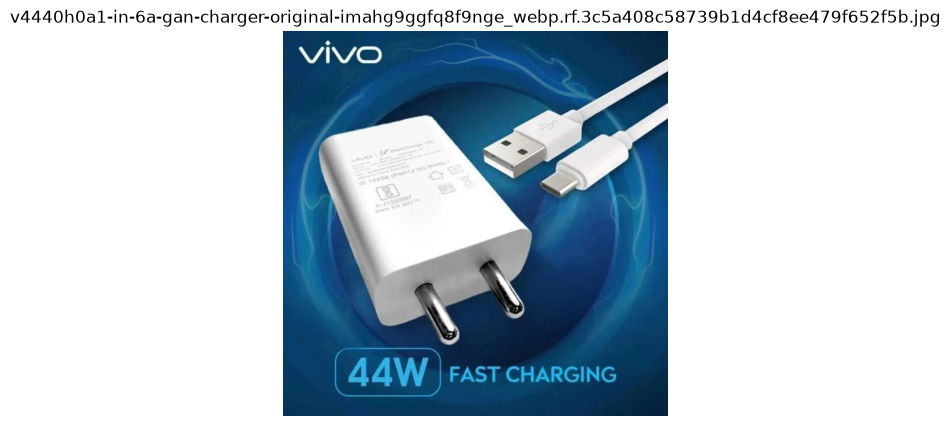

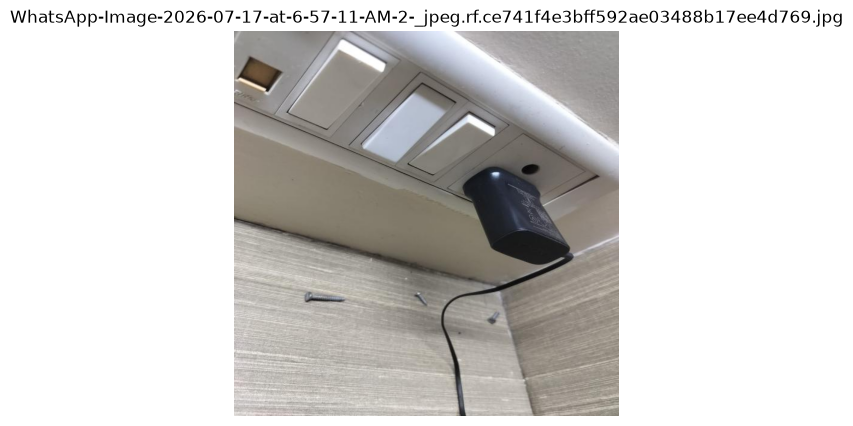

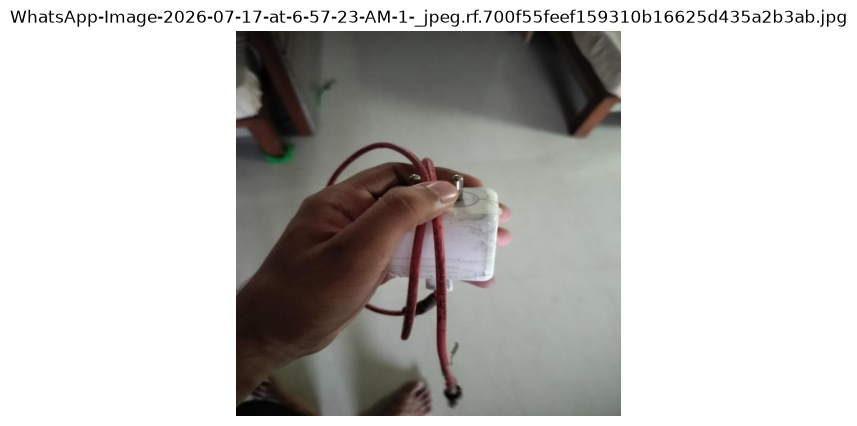


SPLIT: valid


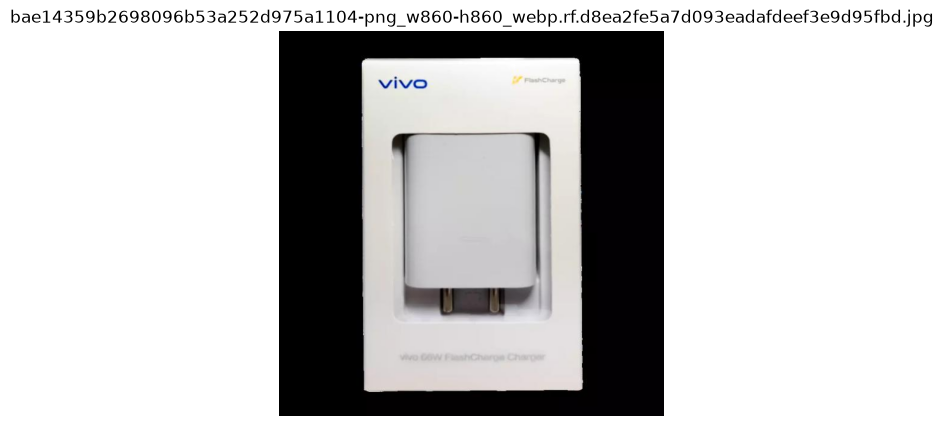

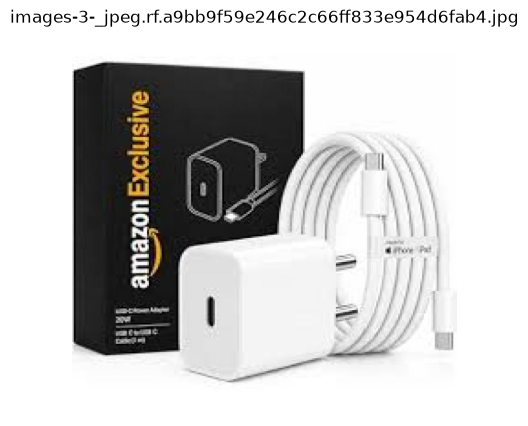

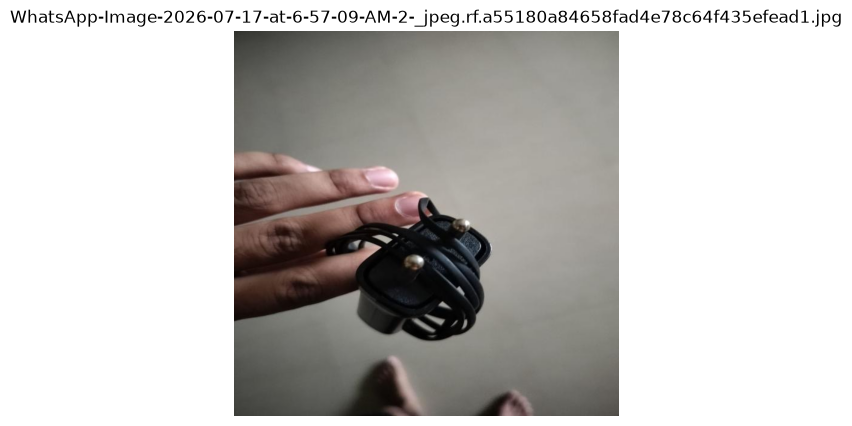

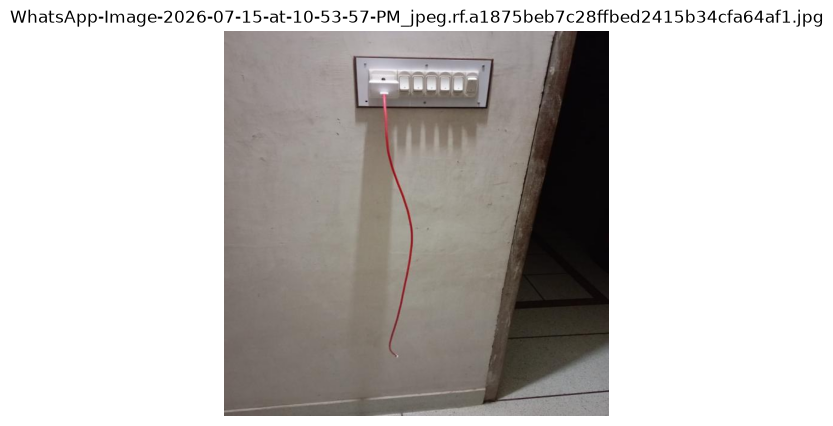

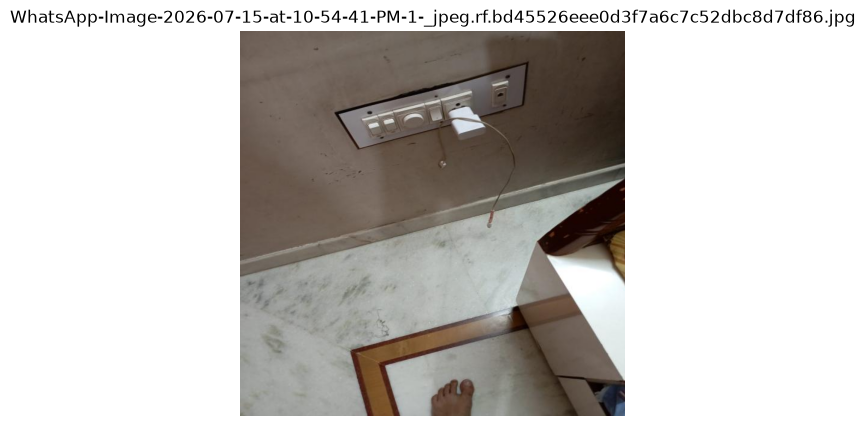


SPLIT: test


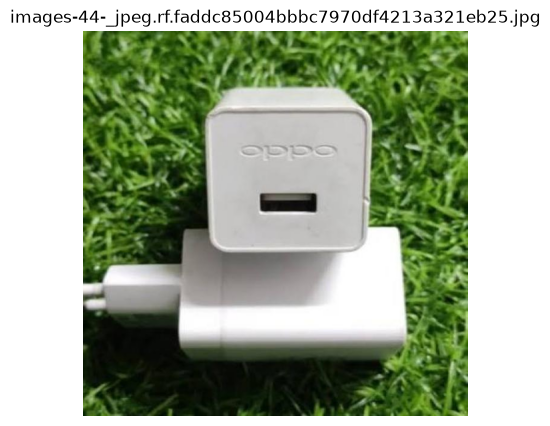

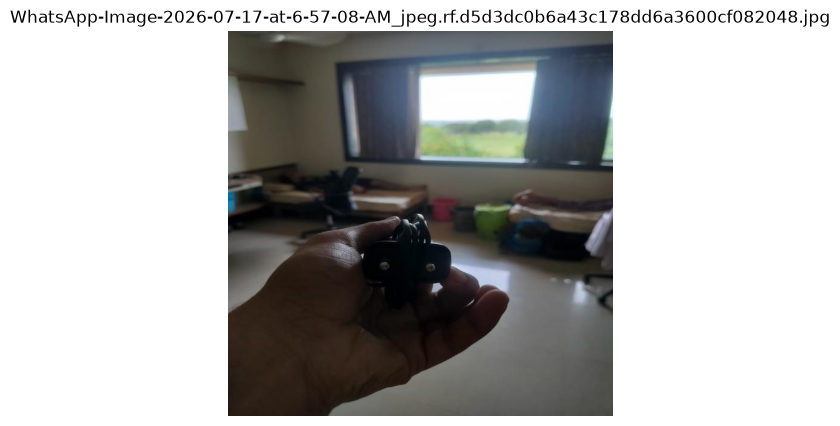

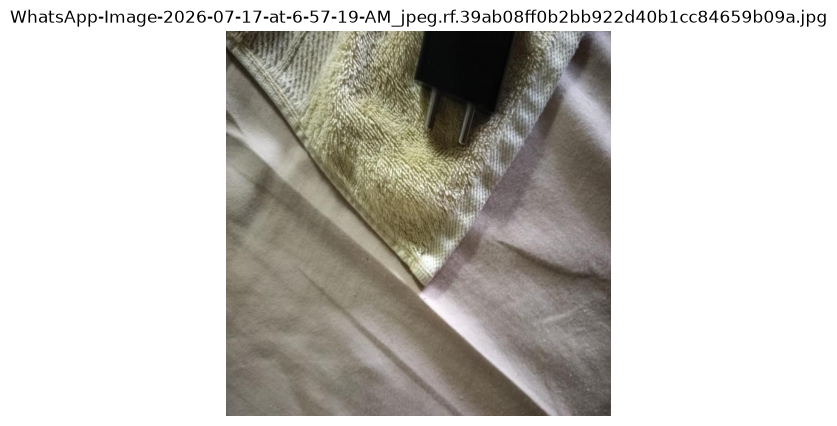

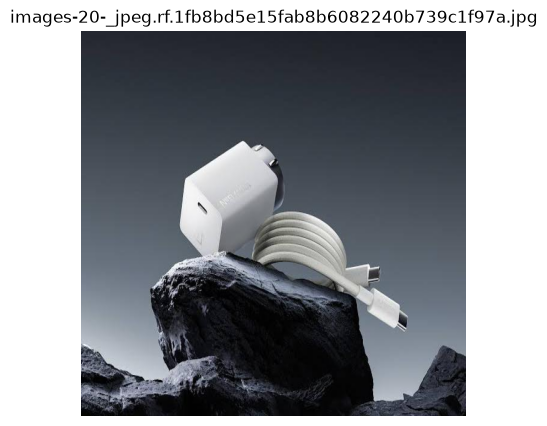

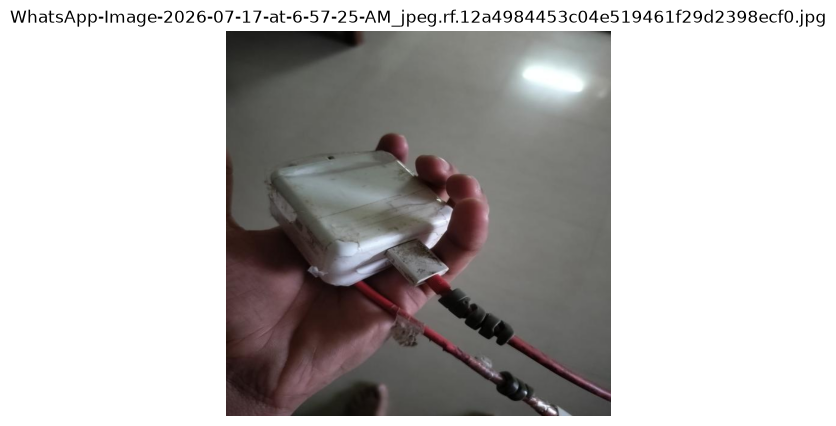

In [12]:
import random
import matplotlib.pyplot as plt

for split in ["train", "valid", "test"]:

    split_images = [
        image_path
        for image_split, image_path in all_images
        if image_split == split
    ]

    samples = random.sample(
        split_images,
        min(5, len(split_images))
    )

    print(f"\nSPLIT: {split}")

    for image_path in samples:

        img = Image.open(
            windows_long_path(image_path)
        )

        plt.figure(figsize=(5, 5))
        plt.imshow(img)
        plt.title(image_path.name)
        plt.axis("off")
        plt.show()

In [13]:
import hashlib

hash_groups = {}

for split, image_path in all_images:

    with open(windows_long_path(image_path), "rb") as f:
        file_hash = hashlib.md5(f.read()).hexdigest()

    hash_groups.setdefault(file_hash, []).append(
        (split, image_path.name)
    )

exact_duplicates = [
    group
    for group in hash_groups.values()
    if len(group) > 1
]

print("Exact duplicate groups:", len(exact_duplicates))

for group in exact_duplicates:
    print(group)

Exact duplicate groups: 0


In [14]:
import imagehash
from PIL import Image

image_hashes = []

for split, image_path in all_images:

    with Image.open(windows_long_path(image_path)) as img:
        phash = imagehash.phash(img)

    image_hashes.append({
        "split": split,
        "file_name": image_path.name,
        "phash": phash
    })


near_duplicates = []

for i in range(len(image_hashes)):
    for j in range(i + 1, len(image_hashes)):

        distance = (
            image_hashes[i]["phash"]
            - image_hashes[j]["phash"]
        )

        if distance <= 4:

            near_duplicates.append({
                "file1": image_hashes[i]["file_name"],
                "split1": image_hashes[i]["split"],
                "file2": image_hashes[j]["file_name"],
                "split2": image_hashes[j]["split"],
                "distance": int(distance)
            })


print("Possible near-duplicate pairs:", len(near_duplicates))

for pair in near_duplicates[:30]:
    print(pair)

Possible near-duplicate pairs: 2
{'file1': 'WhatsApp-Image-2026-07-15-at-10-53-54-PM-2-_jpeg.rf.4a6698603708c95527f28ff1b3ea59a4.jpg', 'split1': 'train', 'file2': 'WhatsApp-Image-2026-07-15-at-10-53-55-PM_jpeg.rf.e2b4880bed69cd866b0153cbb99081e0.jpg', 'split2': 'train', 'distance': 0}
{'file1': 'WhatsApp-Image-2026-07-17-at-6-57-10-AM-1-_jpeg.rf.5092bbd0b008c9f98eab873b966d9636.jpg', 'split1': 'train', 'file2': 'WhatsApp-Image-2026-07-17-at-6-57-10-AM-2-_jpeg.rf.01cd4784eba776223b7541e6d4b108a7.jpg', 'split2': 'train', 'distance': 4}


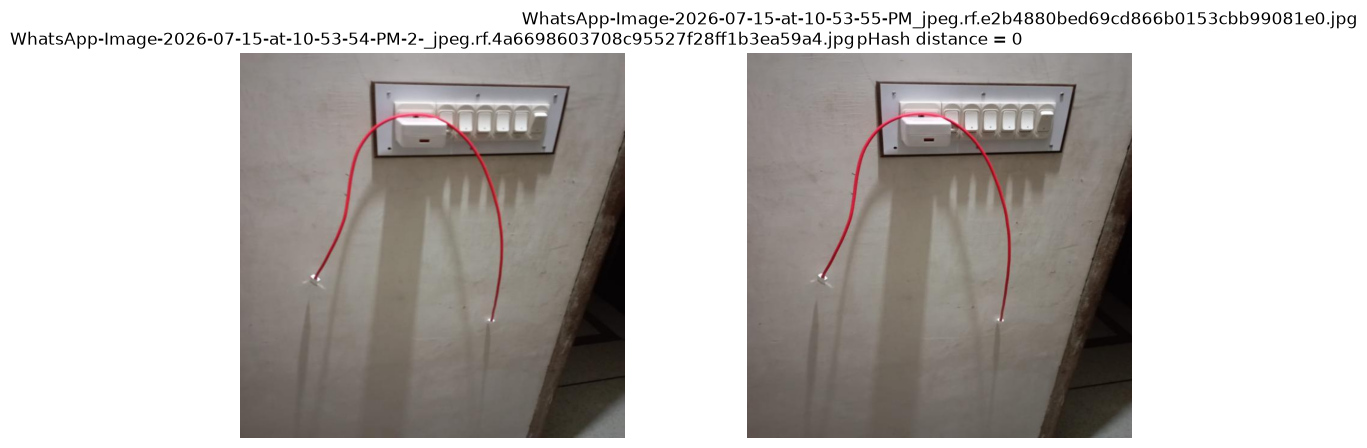

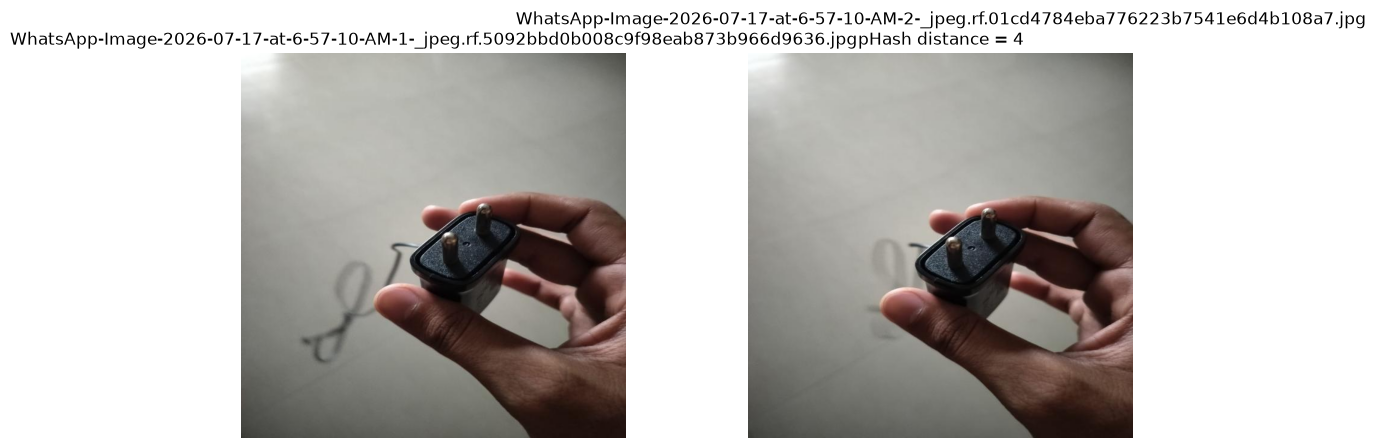

In [15]:
import matplotlib.pyplot as plt
from PIL import Image

for pair in near_duplicates:

    path1 = (
        dataset_path
        / pair["split1"]
        / "images"
        / pair["file1"]
    )

    path2 = (
        dataset_path
        / pair["split2"]
        / "images"
        / pair["file2"]
    )

    img1 = Image.open(windows_long_path(path1))
    img2 = Image.open(windows_long_path(path2))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(img1)
    axes[0].set_title(pair["file1"])
    axes[0].axis("off")

    axes[1].imshow(img2)
    axes[1].set_title(
        f"{pair['file2']}\npHash distance = {pair['distance']}"
    )
    axes[1].axis("off")

    plt.show()

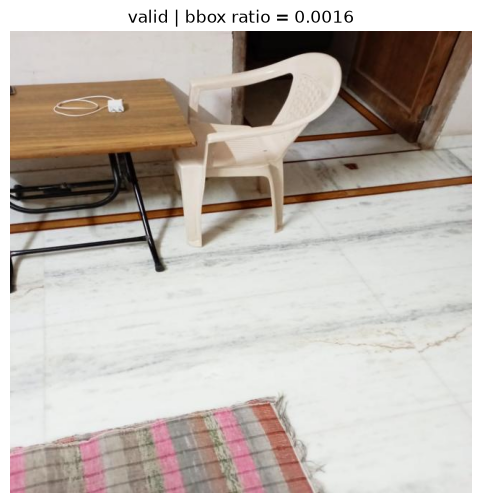

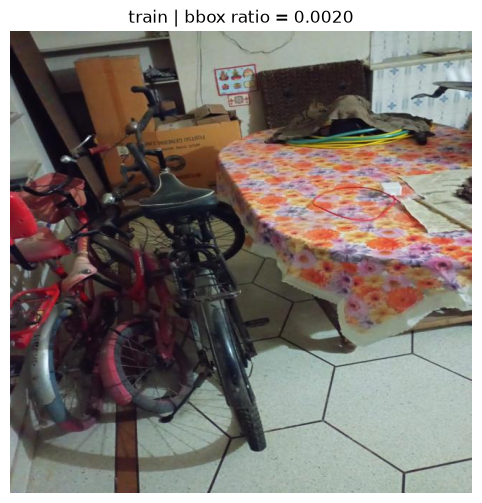

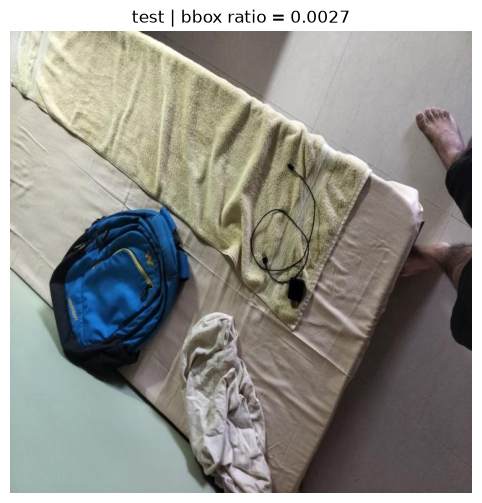

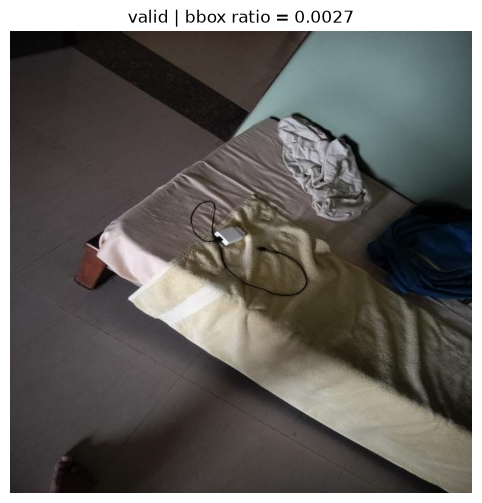

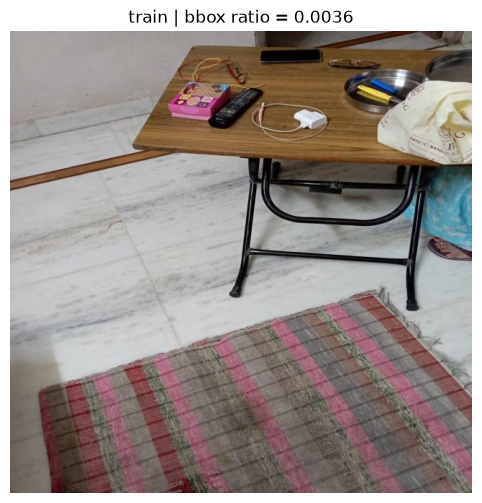

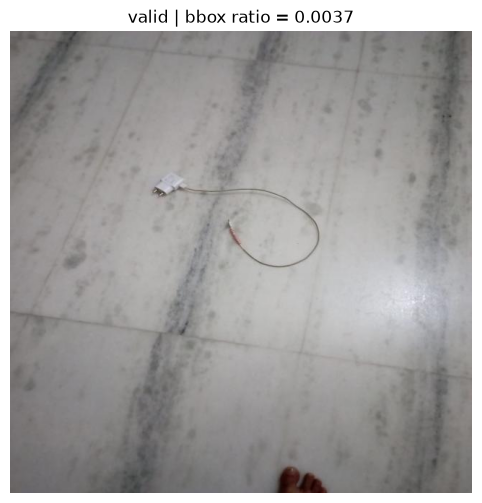

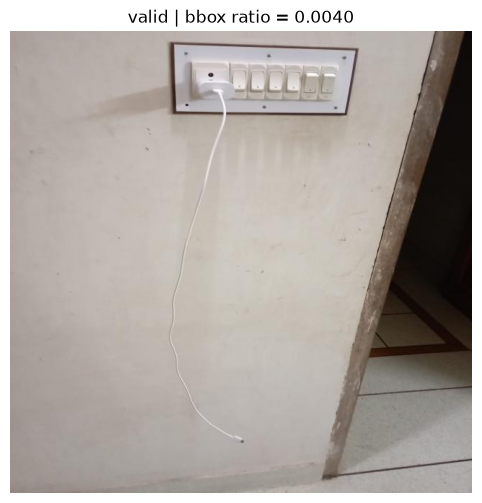

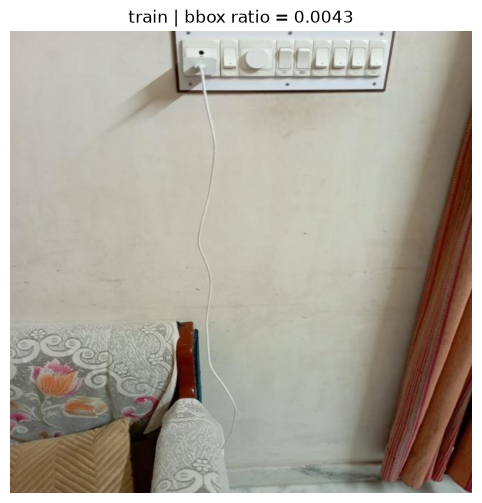

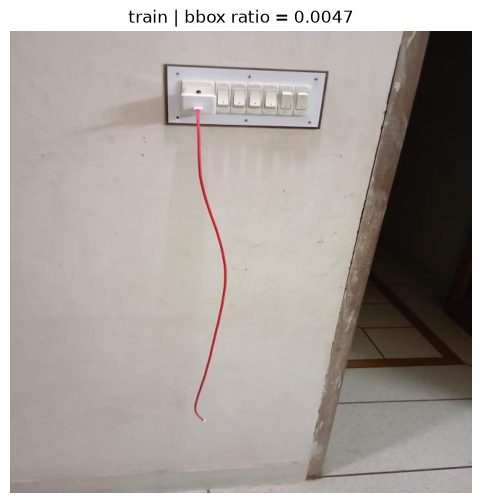

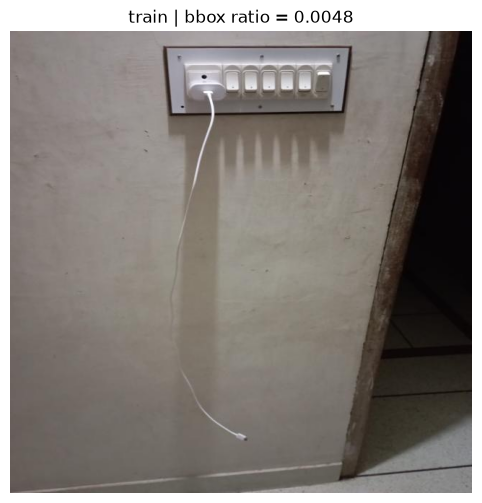

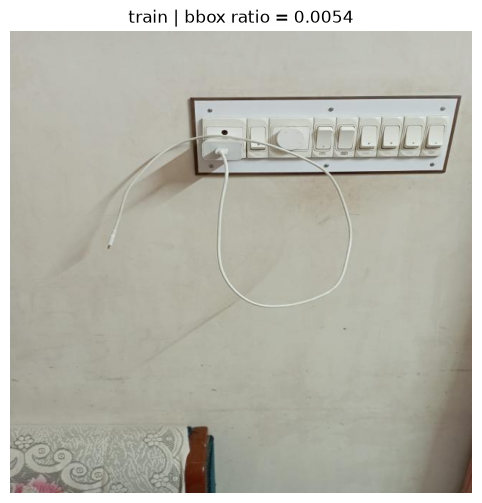

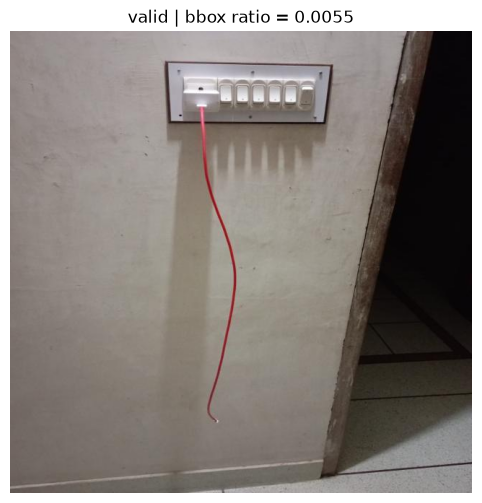

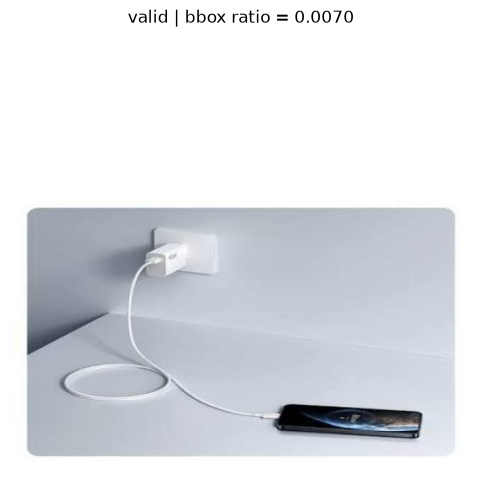

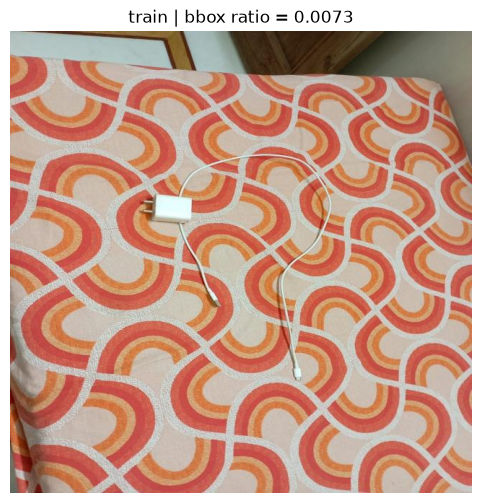

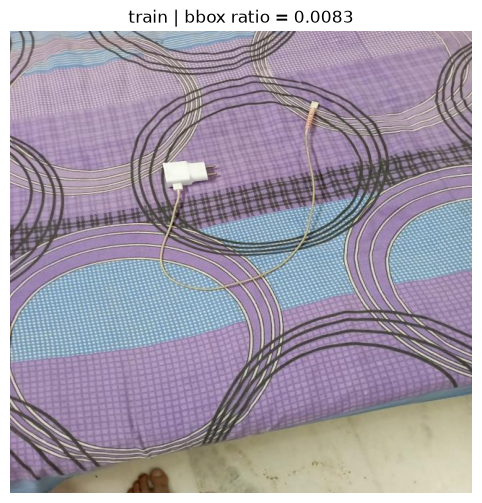

In [16]:
smallest = (
    charger2_df
    .sort_values("largest_bbox_ratio")
    .head(15)
)

for _, row in smallest.iterrows():

    image_path = (
        dataset_path
        / row["original_split"]
        / "images"
        / row["file_name"]
    )

    img = Image.open(windows_long_path(image_path))

    plt.figure(figsize=(6, 6))
    plt.imshow(img)

    plt.title(
        f"{row['original_split']} | "
        f"bbox ratio = {row['largest_bbox_ratio']:.4f}"
    )

    plt.axis("off")
    plt.show()

In [17]:
duplicate_map = {
    'WhatsApp-Image-2026-07-15-at-10-53-54-PM-2-_jpeg.rf.4a6698603708c95527f28ff1b3ea59a4.jpg': 'DUP01',
    'WhatsApp-Image-2026-07-15-at-10-53-55-PM_jpeg.rf.e2b4880bed69cd866b0153cbb99081e0.jpg': 'DUP01',

    'WhatsApp-Image-2026-07-17-at-6-57-10-AM-1-_jpeg.rf.5092bbd0b008c9f98eab873b966d9636.jpg': 'DUP02',
    'WhatsApp-Image-2026-07-17-at-6-57-10-AM-2-_jpeg.rf.01cd4784eba776223b7541e6d4b108a7.jpg': 'DUP02'
}

In [18]:
manifest2_df = charger2_df.copy()

manifest2_df["source_dataset"] = "Mobile Charger Detection Roboflow v1"
manifest2_df["original_label"] = "mobile_charger"
manifest2_df["esafe_label"] = "charger_adapter"

manifest2_df["duplicate_group"] = (
    manifest2_df["file_name"]
    .map(duplicate_map)
    .fillna("")
)

# Flag only — NOT automatic rejection
manifest2_df["low_prominence_flag"] = (
    manifest2_df["largest_bbox_ratio"] < 0.03
)

manifest2_df["selection_status"] = "REVIEW"

manifest2_df = manifest2_df[
    [
        "file_name",
        "source_dataset",
        "original_split",
        "original_label",
        "esafe_label",
        "object_count",
        "largest_bbox_ratio",
        "low_prominence_flag",
        "duplicate_group",
        "selection_status"
    ]
]

print(manifest2_df.shape)
print("Duplicate images:", (manifest2_df["duplicate_group"] != "").sum())
print("Low-prominence flagged:", manifest2_df["low_prominence_flag"].sum())

(223, 10)
Duplicate images: 4
Low-prominence flagged: 47


In [19]:
output_path = "../../data/metadata/charger_source2_manifest.csv"

manifest2_df.to_csv(output_path, index=False)

check_df = pd.read_csv(output_path)

print("Saved:", output_path)
print(check_df.shape)

Saved: ../../data/metadata/charger_source2_manifest.csv
(223, 10)


# EDA Conclusions — Mobile Charger Detection Roboflow v1 → `charger_adapter`

## Dataset Structure

- Source: Roboflow Universe — Mobile Charger Detection.
- Version: 1.
- Licence: CC BY 4.0.
- Original class: `mobile_charger`.
- E-Safe mapping: `charger_adapter`.

The downloaded dataset contains 223 images:

- Train: 156
- Validation: 45
- Test: 22

All 223 images have corresponding YOLO annotation files.

The dataset contains 284 annotated charger objects.

Objects per image:

- 194 images contain 1 charger.
- 20 images contain 2 chargers.
- 4 images contain 3 chargers.
- A small number of images contain 4–11 chargers.

All annotation objects use class ID 0 (`mobile_charger`).

## Image Quality

- All 223 images are 640 × 640.
- No corrupt images were detected.
- No images were missing annotation files.
- No annotation files were missing their corresponding image.

## Visual Observations

Manual inspection showed that:

- The dataset strongly represents mobile/wall charging adapters.
- Both product-style and real-world photographs are present.
- Real-world examples include chargers on beds, floors, tables and walls, as well as chargers connected to switchboards/sockets.
- Hands, charging cables, phones, packaging and other contextual objects sometimes appear in the images.
- Background diversity is substantially greater than Charger Source 1.
- Some advertisement/product-composite images are present.
- In most inspected images, the charger remains clearly identifiable even when other objects are visible.

This source complements Charger Source 1 well because Source 1 mainly represents laptop/power adapters, whereas Source 2 provides much stronger mobile-wall-charger and household-context coverage.

## Object Prominence

Largest charger bounding-box area ratio:

- Mean: 0.1553 (~15.53%)
- Median: 0.0935 (~9.35%)
- 25th percentile: 0.0352 (~3.52%)
- 75th percentile: 0.2537 (~25.37%)
- Minimum: 0.00165 (~0.16%)
- Maximum: 0.6779 (~67.79%)

Therefore, chargers are considerably smaller in the frame than in Source 1.

Manual inspection of the lowest-prominence examples showed that many are still valid charger photographs. Chargers may appear small because they are photographed from a wide angle, placed on a floor/bed, or connected to a distant wall socket.

These images should not be automatically rejected using a fixed bounding-box threshold. Low-prominence images will instead be flagged for review during final preprocessing.

## Augmentation and Duplicate Analysis

No obvious augmentation patterns such as `flipped`, `rotate`, `blur`, or `bright` were detected in filenames.

No exact byte-identical duplicate groups were found.

Perceptual hashing identified two near-duplicate pairs.

Both pairs were manually inspected and confirmed to represent duplicate/effectively identical images.

They are recorded as:

- `DUP01`
- `DUP02`

The raw files will remain unchanged.

## Main Strengths

- Strong mobile charger representation.
- Real-world household backgrounds.
- Chargers connected to sockets and switchboards.
- Greater environmental diversity than Source 1.
- Mixture of clean product images and lower-quality natural photographs.
- Very little evidence of artificial augmentation inflation.

## Main Limitations

- Charger objects are relatively small in many images.
- Some images contain distracting contextual objects.
- Some advertisement/composite product images are present.
- A few very wide-angle images may require cropping or rejection during final preprocessing.

Overall, this is a useful complementary source for the E-Safe Dataset A `charger_adapter` class.

# Future Work / Preprocessing Decisions — Charger Source 2

- Keep the raw downloaded dataset unchanged.
- Map `mobile_charger` to the E-Safe label `charger_adapter`.
- Preserve the original Roboflow split only as metadata.
- Final Dataset A splitting will be performed later after sources are merged and cleaned.
- Remove one redundant member from each confirmed duplicate group during preprocessing.
- Do not automatically reject images based only on bounding-box area.
- Use `low_prominence_flag` only to identify images requiring manual review.
- Review wide-angle images where the charger occupies a very small part of the frame.
- Where appropriate, consider padded charger crops during preprocessing while retaining useful surrounding context.
- Reject images only when the charger is too small, partial or ambiguous to support reliable full-image classification.
- Preserve useful real-world images containing sockets, hands, phones or household backgrounds because they improve domain diversity.
- Source 2 should complement rather than replace Source 1.
- Dataset A remains an item-recognition dataset; visible charger damage belongs to Dataset B.